# Task 2: Credit Risk Prediction
### Objective:
Predict whether a loan applicant is likely to default on a loan.
### Dataset:
Loan Prediction Dataset (available on Kaggle)
### Instructions:
- Handle missing data appropriately.
- Visualize key features such as loan amount, education, and income.
- Train a classification model like Logistic Regression or Decision Tree.
- Evaluate the model using accuracy and a confusion matrix.

### Skills:
- Data cleaning and handling missing values
- Exploratory Data Analysis (EDA)
- Binary classification using machine learning
- Model evaluation using confusion matrix and accuracy

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")

In [58]:
train = pd.read_csv("loanPredictionTrain.csv")
test = pd.read_csv("loanPredictionTest.csv")

In [59]:
train.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [60]:
test.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [61]:
print(f"training shape = {train.shape}")
print(f"testing shape = {test.shape}")

training shape = (614, 13)
testing shape = (367, 12)


In [62]:
print("Missing values before cleaning:\n", train.isnull().sum())

Missing values before cleaning:
 Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [63]:
train['LoanAmount'] = train['LoanAmount'].fillna(train['LoanAmount'].median())
train['Loan_Amount_Term'] = train['Loan_Amount_Term'].fillna(train['Loan_Amount_Term'].median())
train['Credit_History'] = train['Credit_History'].fillna(train['Credit_History'].median())

In [64]:
categorical_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed']
for col in categorical_cols:
    train[col] = train[col].fillna(train[col].mode()[0])

In [65]:
print("\nMissing values after cleaning:\n", train.isnull().sum())


Missing values after cleaning:
 Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


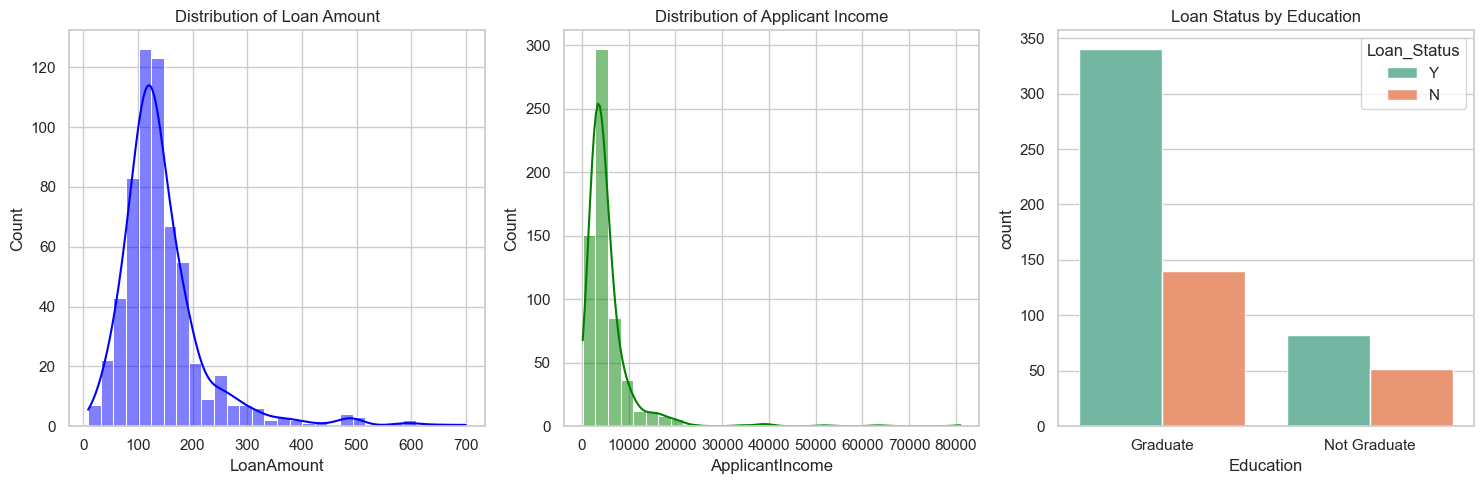

In [66]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(train['LoanAmount'], kde=True, bins=30, color='blue')
plt.title('Distribution of Loan Amount')

plt.subplot(1, 3, 2)
sns.histplot(train['ApplicantIncome'], kde=True, bins=30, color='green')
plt.title('Distribution of Applicant Income')

plt.subplot(1, 3, 3)
sns.countplot(x='Education', hue='Loan_Status', data=train, palette='Set2')
plt.title('Loan Status by Education')

plt.tight_layout()
plt.show()

In [67]:
train['Loan_Status'] = train['Loan_Status'].astype(str).str.strip().str.upper()

train['Loan_Status'] = train['Loan_Status'].map({'Y': 1, 'N': 0})

print(train['Loan_Status'].value_counts())

Loan_Status
1    422
0    192
Name: count, dtype: int64


In [69]:
le = LabelEncoder()
cols_to_encode = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
for col in cols_to_encode:
    train[col] = le.fit_transform(train[col])

features = ['Loan_ID', 'Loan_Status']

X = train.drop(features, axis=1)
y = train['Loan_Status']

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (491, 11)
Testing data shape: (123, 11)


In [75]:
model = LogisticRegression(max_iter=7000, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Model Accuracy: 78.05%



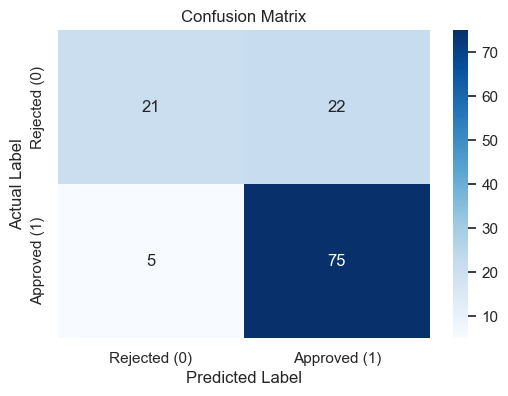

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.49      0.61        43
           1       0.77      0.94      0.85        80

    accuracy                           0.78       123
   macro avg       0.79      0.71      0.73       123
weighted avg       0.79      0.78      0.76       123



In [76]:
acc = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {acc * 100:.2f}%\n")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Rejected (0)', 'Approved (1)'], 
            yticklabels=['Rejected (0)', 'Approved (1)'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

# Print detailed classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))